# Week-2 Day-3

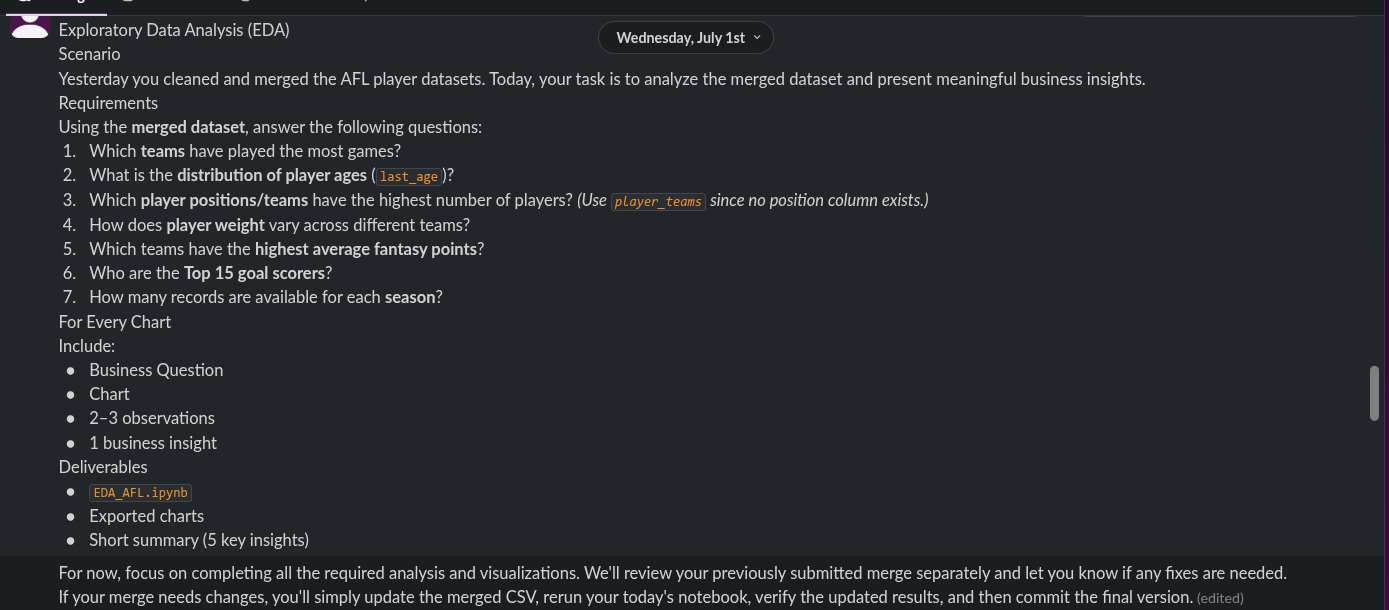

1. Which teams have played the most games?
2. What is the distribution of players ages (last_age)?
3. Which player positions/teams have the highest number of players?
4. How does payer weight vary across different teams?
5. Which teams have the highest average fantasy points?
6. Who are the Top 15 goal scorers?
7. How many records are available for each season?

In [59]:
# some ai code to have consistent styled matplotlib plots
import matplotlib.pyplot as plt

# consistent styling across all 7 charts
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "x"
plt.rcParams["grid.alpha"] = 0.3

BLUE = "#2a78d6"  # single hue used for every ranking/magnitude chart below


In [60]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../Day-2/final/merged_players.csv")
df.head()

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,teams_list
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,1984-05-14,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,https://afltables.com/afl/stats/players/G/Gary...,['Gary'],"['Geelong Cats', 'Gold Coast Suns']"


## 1. Which teams have played the most games?


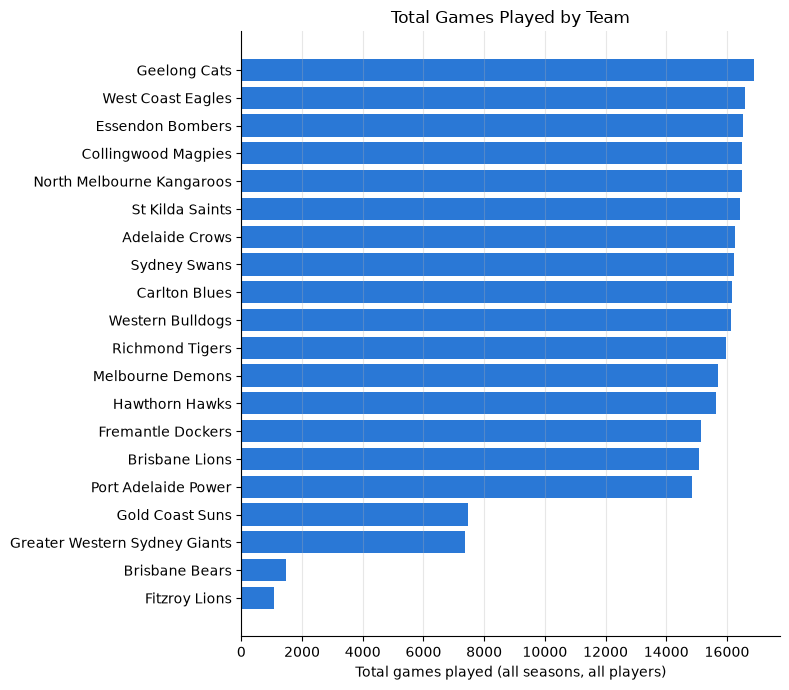

In [61]:
q1 = df.groupby("team")["games_played"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q1.index, q1.values, color=BLUE)
ax.set_xlabel("Total games played (all seasons, all players)")
ax.set_title("Total Games Played by Team")
plt.tight_layout()
plt.show()


- uhhh, ok this cannot be correct, a team playing over 10k games is insane. AI isn't helping here. the df is per player, per team, per season, not just per team, that is why this won't work.
- I will use AI to get this done, I imagine we have to groupby both team and year somehow and then print games_played and then it should work

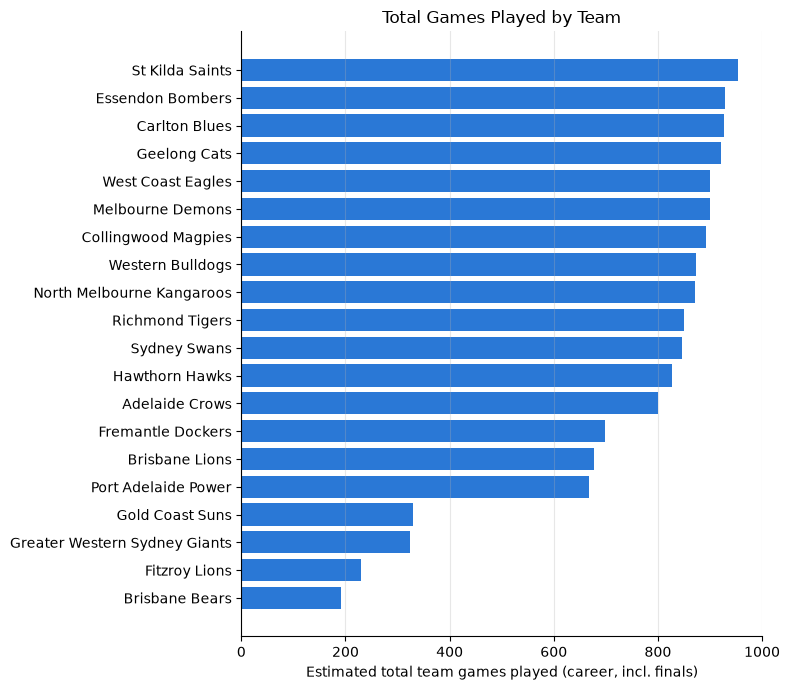

In [62]:
per_split = df.groupby(["team", "year", "is_finals"])["games_played"].max()
q1 = per_split.groupby("team").sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q1.index, q1.values, color=BLUE)
ax.set_xlabel("Estimated total team games played (career, incl. finals)")
ax.set_title("Total Games Played by Team")
plt.tight_layout()
plt.show()


In [63]:
fig.savefig("figures/q1")

- ok, this was a bit tricky, I will print the reasoning claude gave, I think I understand it, at least half way:

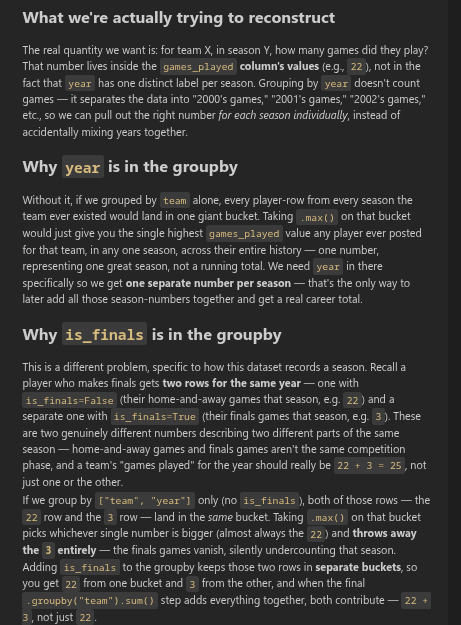

### 1. **Answer:** **St Kilda Saints** with 953 games

btw, this whole plt.subplots is ai-ed so worth understanding:
1. the two objects we get (fig and ax) from plt.subplots are used to control the chart instance
   1. its pretty simple, fig is for controlling the size of the canvas and also for fig.savefig
   2. ax refers to the actual area inside the canvas where the chart will be drawn. we use ax.<charttype> to draw the chart and then ax.set_xlabel and ax.set_ylabel and ax.set_title and thats it. quite simple
2. below, in question 2, just as an experiment, I'm ganna make that histogram chart with seaborn instead, and I assume the nice settings at the top of the notebook for consistent styling, that won't apply to that graph since I used seaborn and not plt, lets try


---

## 2. What is the distribution of players ages (last_age)?

- whenever you hear "distribution", always go for a simple histogram

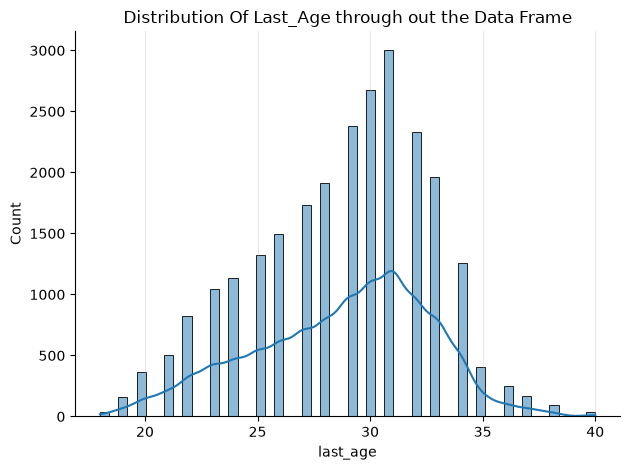

In [64]:
sns.histplot(df["last_age"], kde=True)
plt.title("Distribution Of Last_Age through out the Data Frame")
plt.tight_layout()
plt.show()


- and as you can see, I used sns and all the nice coloring etc is gone sadly, lets use plt and the subplot technique that AI used

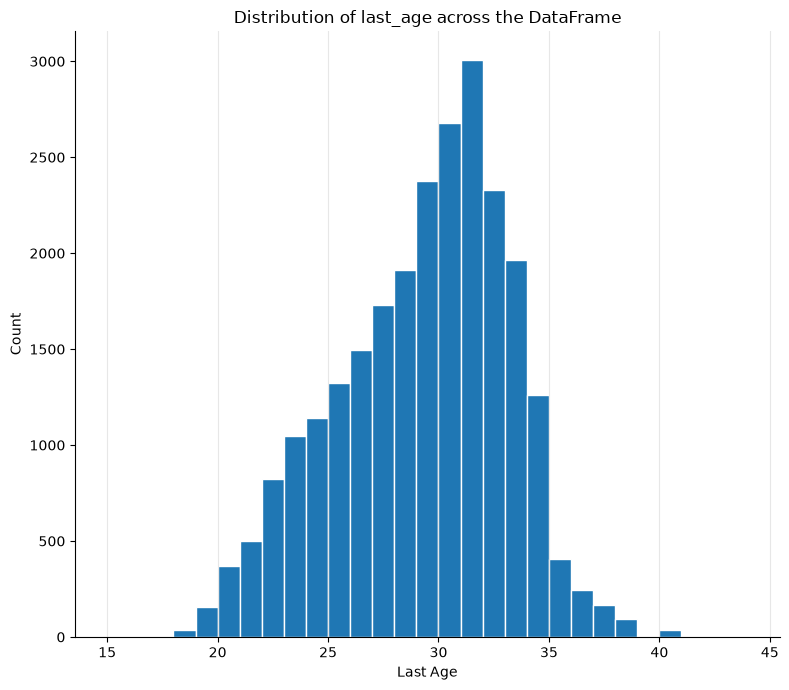

In [65]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.hist(df["last_age"], edgecolor="WHITE", bins=range(15, 45))
ax.set_title("Distribution of last_age across the DataFrame")
ax.set_xlabel("Last Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [66]:
fig.savefig("figures/q2")

**Observations**:
- The age distribution is basically from around 18 ish to around 40 or 41. 
- the minimum age seems to be 18, and the maximum seems to be around 40
- both tails of the graph are hella narrow, not many players there, so safe to say that the average AFL player is arounf 25-35 years old.
- most players are in the range of 29 to 32

**Business Insight**:
- I don't think we can get anything out of just age tbh. One simple insight would be that "replacement planning" should start around 30-33 years so there is enough time, by the time a player retires, another younger, new player should be ready to replace him

### 2. **Answer:** The age distribution is from 18 to 40 ish with a high concentration from 25-35, most players are in that age range.

---

## 3. Which player positions/teams have the highest number of players?

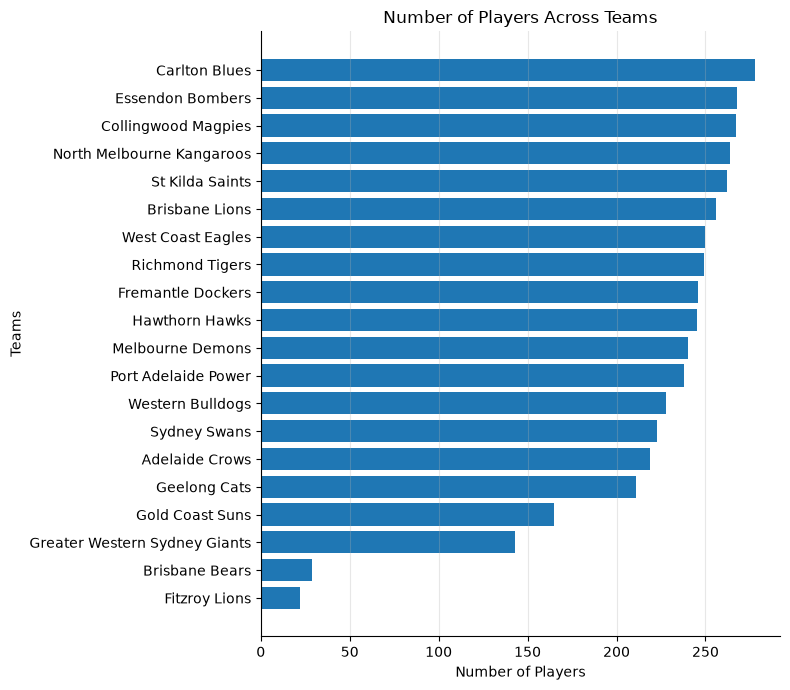

In [67]:
q3 = df.groupby("team")["id"].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q3.index, q3.values)
ax.set_title("Number of Players Across Teams")
ax.set_xlabel("Number of Players")
ax.set_ylabel("Teams")
plt.tight_layout()
plt.show()

In [68]:
fig.savefig("figures/q3")

**Observations**:
- We know quite well that the dataset is from 1983 to 2025, and the bottom two teams, fitzoy lions and brisbane bears have had like 20-35 players total, IN 42 YEARS???? That seemed very suspicious, so I made a google search, here are the results:


| Google Search Results |
| :---: |
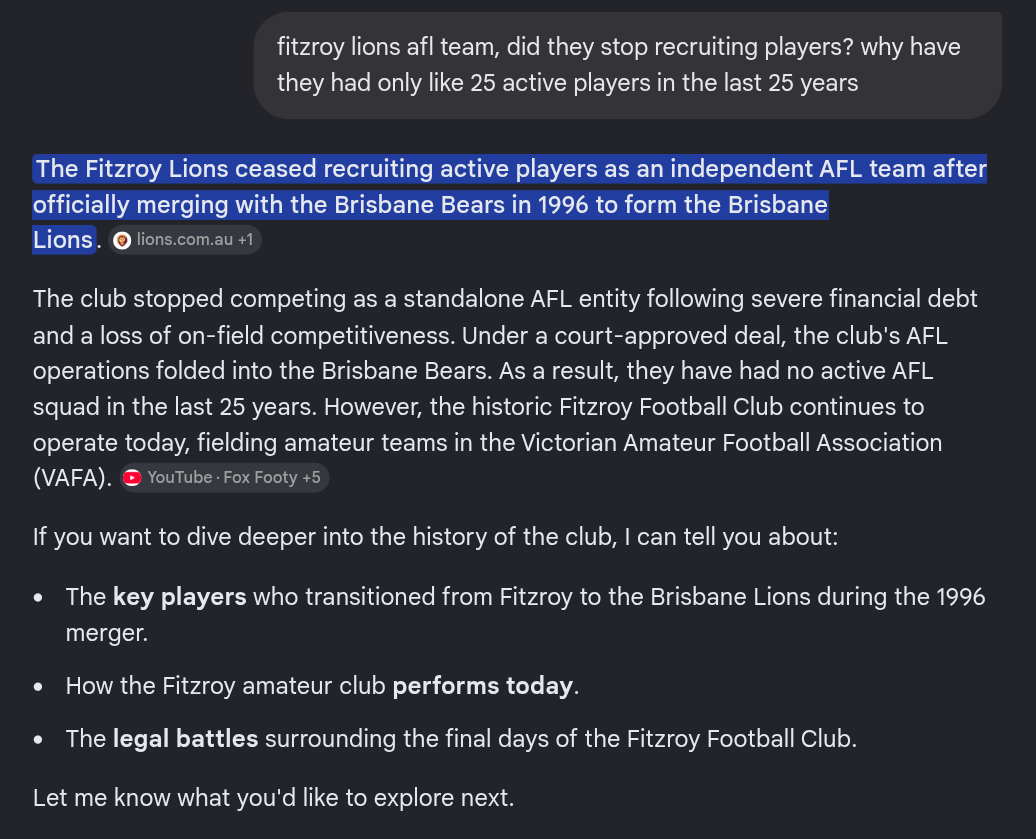
 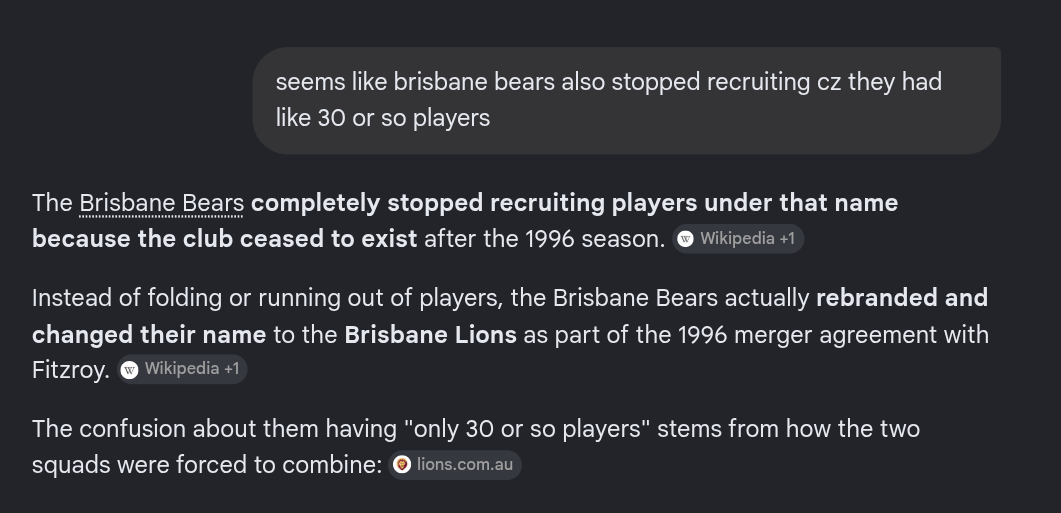


- ok wow, I was right, both fitzoy lions and brisbane bears went outta existence in around 1996, and turned into brisbane lions after the merger (look at team number 6 in my barchart above bro). Great finding, yes I am complimenting myself
- Ok, observation number 2 is that carlton blues of course have the most players
- observation 3 is also quite simple, most teams have had over 200 players over the 43 year timespan


**Business Insight**:
- Again, with player count alone, it doesn't really let you derive some super useful outcome. but if we can find number of playeres active over the seasons, then we can basically find the retention rate for each team, as in which teams keeps players for the longest time. This could serve as an insight to recruitment teams I suppose (and yes I know that won't be a direct insight from this chart alone, but this chart alone doesn't tell much)

### 3. **Answer:** Carlton Blue

---

## 4. How does player weight vary across different teams?

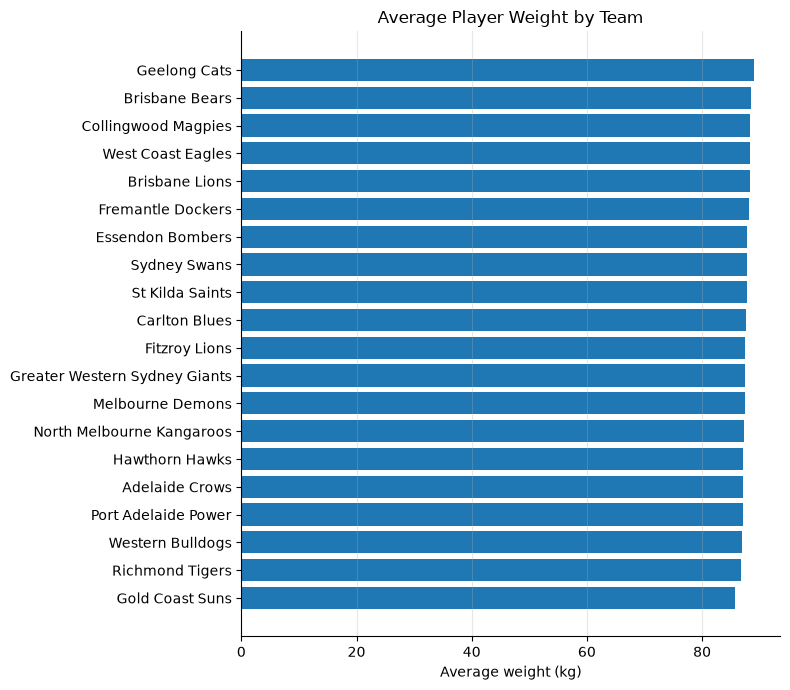

In [69]:
q4 = df.groupby("team")["weight"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q4.index, q4.values)
ax.set_xlabel("Average weight (kg)")
ax.set_title("Average Player Weight by Team")
plt.tight_layout()
plt.show()


In [70]:
fig.savefig("figures/q4")

- uhhh, ok, well, weight does not vary much at all across teams, that is the correct answer. I think we can find weight ditribution inside a team as well using lots of boxplots but Idk the code, I will ai that and make that graph too so at least this is a tiny bit interesting

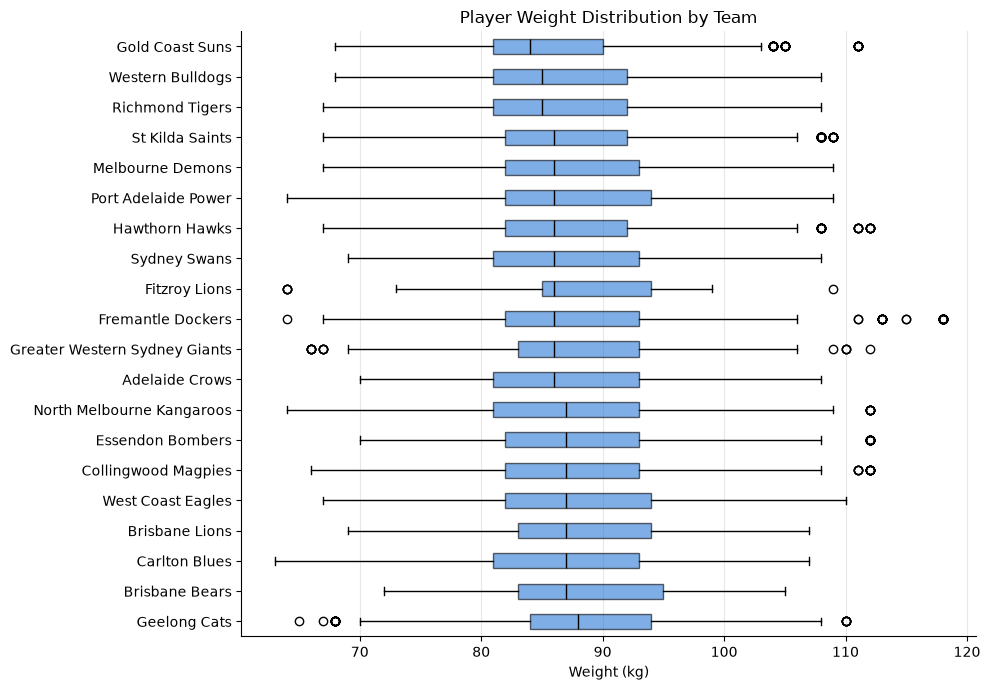

In [71]:
team_order = df.groupby("team")["weight"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 7))
data = [df.loc[df["team"] == t, "weight"].dropna() for t in team_order]
bp = ax.boxplot(data, orientation="horizontal", tick_labels=team_order, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6), medianprops=dict(color="black"))
ax.set_xlabel("Weight (kg)")
ax.set_title("Player Weight Distribution by Team")
plt.tight_layout()
plt.show()


In [72]:
fig.savefig("figures/q4-boxplot")

- that is a very pretty graph. Lets observe now


**Observations**:
- ok, so from my original graph, the variation is very mild across teams, most players weight over 80 and below 100
- from this crazy boxplot graph, its clear that each team has several outliers, there are players who weight only around 65 kgs, but only a tiny amount.
- there are some players who weight over a 110kgs even, which is quite insane, but only a few outliers.
- generally speaking, the amount of variance is very low

**Business Insights**:
- If you are a recruitement agency giving advice to recruits, tell them to be around 85 to 95kgs, that is the sweet spot for getting becoming an AFL player. But other than that, weight is not a meaningful team level differentiator, all the variance is within-team, not across team (this question was about across diff teams)

### 4. **Answer:** Weight doesn't vary almost at all across teams

---

## 5. Which teams have the highest average fantasy points?

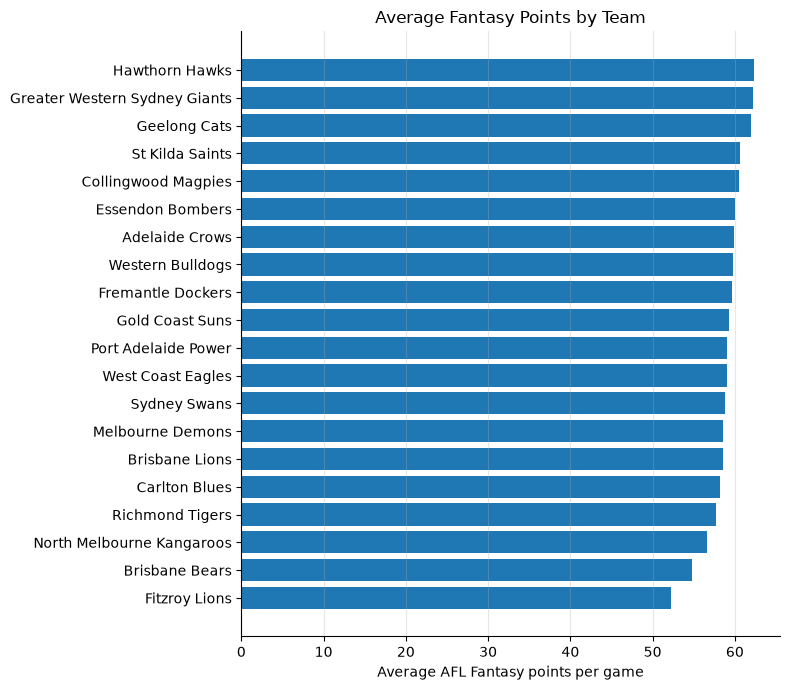

In [73]:
q5 = df.groupby("team")["avg_fantasy_points"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q5.index, q5.values)
ax.set_xlabel("Average AFL Fantasy points per game")
ax.set_title("Average Fantasy Points by Team")
plt.tight_layout()
plt.show()


In [74]:
fig.savefig("figures/q5")

**Observations**:
- first observation is that fantasy points do not vary too much across teams, fitzoy lions and brisbane bears have the lowest but that is probably only because those two teams retired around 1996
- the north melbourne kangaroos are at the bottom of the chart, and they are an active team, with fantasy points around 55, and considering that the top team has fantasy points around 65, that is not massive variance, but it does mean that earning fantasy points is probably not very easy
- The top 3 are doing significantly better than the rest of the teams it seems, the diff between the top 3 and the rest is quite significant


**Business Insight**:
- If you are betting on who would perform the best, you should probably bet on the top 3 since fantasy points are calculated using a points system that calculates performance (I just found that out after googling, didn't even know what fantasy points are)

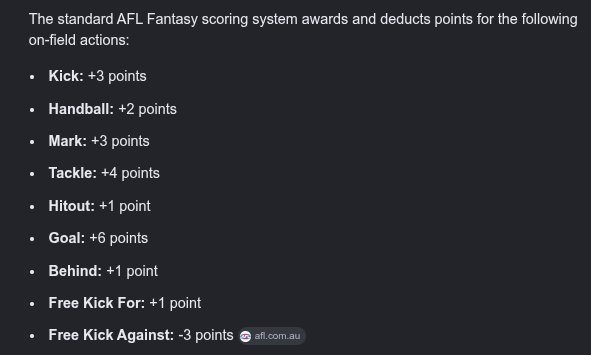

### 5. **Answer:** Hawthorn Hawks have the highest Fantasy Points in the dataset

---

## 6. Who are the Top 15 goal scorers?

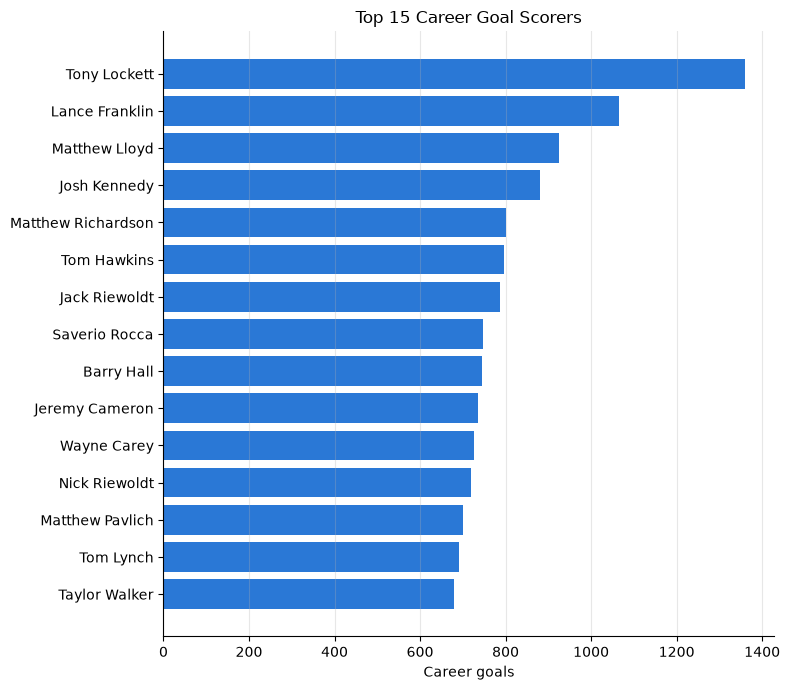

In [75]:
q6 = df.groupby("name")["goals"].sum().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(q6.index, q6.values, color=BLUE)
ax.set_xlabel("Career goals")
ax.set_title("Top 15 Career Goal Scorers")
plt.tight_layout()
plt.show()


In [76]:
fig.savefig("figures/q6")

**Observations**:
- the first obvious thing to note is that Tony has an insane lead, its quite insane, he has almost 1400 goals and the second person, Lance has only around 1050, so Tony has a lead of 350, even though the dataset is not current and out of date, I bet Tony is probably still number 1 in 2026:

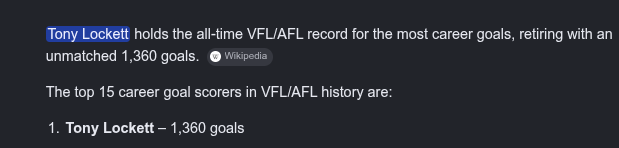

- yup, tony is still number 1
- ok, second observation is that after the top 4, the graph kinda evens out, almost everyone from 5 to 15 have scored around 700-800 goals, but perhaps some of these players are not even playing anymore so that should be thought of
- Taylor is at the bottom with around 680 ish goals, so its safe to say that if you want to be in the top 15 in the AFL, you have to score at least 600-700 goals

**Business Insight**:
- You can safely bet on Tony being the number 1 goal scorer for the new year or two if he doesn't retire or get injured

### 6. **Answer:** here is the top 15 list (you can just view from the graph too btw):
1. Tony Lockett
2. Lance Franklin
3. Mathew Lloyd
4. Josh Kennedy
5. Mathew Richardson
6. Tom Hawkins
7. Jack Riewoldt
8. Saverio Rocca
9. Barry Hall
10. Jeremy Cameron
11. Wayne Carey
12. Nick Riewoldt
13. Mathew Pavlich
14. Tom Lynch
15. Taylor Walker


---

## 7. How many records are available for each season?

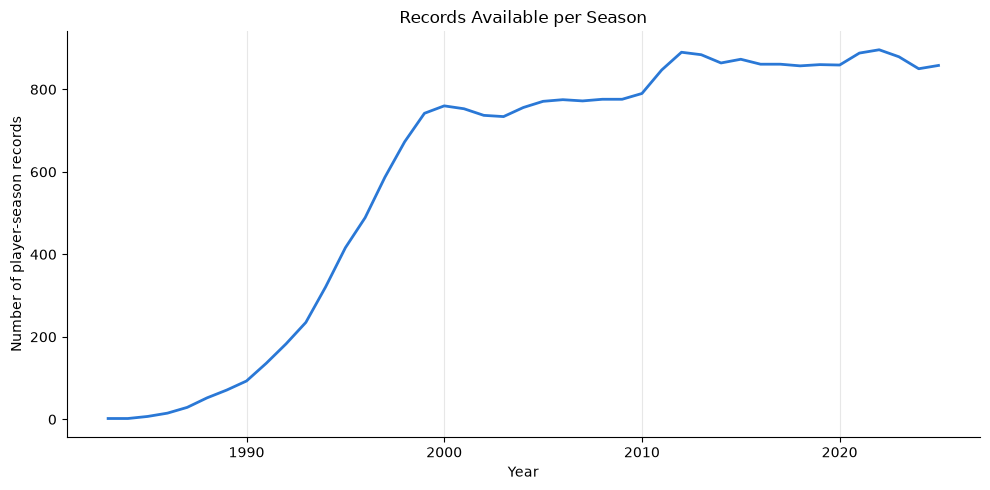

In [77]:
q7 = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q7.index, q7.values, color=BLUE, linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Number of player-season records")
ax.set_title("Records Available per Season")
plt.tight_layout()
plt.show()


In [78]:
fig.savefig("figures/q7")

**Observations**:
- The record count grows absurdly from 1990s onwards, the curve gets hella steap, so I think its quite obvious that this dataset does not have a lot of data prior to 1990, or even 1995
- The dataset has way more records (simply rows) from 1995 onwards, so doing some comparison between 1983-1990s and the 2000s would be extremely skewed and unfair since almost the entire dataset has records from after 1995
- it seems like the last 10 years are more or less flat, so data collection has sorta stabalized since 2012 onwards



**Business Insight**:
- Any trend analysis that we do should be fully aware of that fact that the early years have drastically less records. Other than that, this is an analysis of the actual dataset, it tells nothing about the actual data, so I can't really give you a specific business insight into the sport from just this. Although, its a good time to get into betting  since now you have the most historical data and you can make eduated guesses much better than before

In [79]:
# to answer the question exactly, since its hard to tell exact values from line graph
print(q7)


year
1983      2
1984      2
1985      7
1986     15
1987     29
1988     52
1989     71
1990     93
1991    136
1992    183
1993    235
1994    321
1995    416
1996    489
1997    587
1998    673
1999    742
2000    760
2001    753
2002    737
2003    734
2004    756
2005    771
2006    775
2007    772
2008    776
2009    776
2010    790
2011    847
2012    890
2013    884
2014    864
2015    873
2016    861
2017    861
2018    857
2019    860
2020    859
2021    888
2022    896
2023    879
2024    850
2025    858
dtype: int64


### 7. **Answer:** Please view the output above, the last cell python cell in the notebook

---

## Five Point Summary

1. Cumulative stats like number of games played and goals and total players mostly just shows how long a team has been in the AFL and playing, it doesn't really reflect the quality of that team as much
2. AFL careers cluster very tightly around 29-31 age
3. Tony leads the group by over 300 goals, he is a complete outlier for some reason
4. Player weight is not a good indicator of anything as far as across team comparison is concerned, it has barely any variance.
5. Whatever you do with this dataset, keep in mind that the early years have much less records so be careful about that skew.
6. The AFL is fairly competitive and most teams are in the same sorta boat as evident by the fantasy scores chart, ranking change frequently